In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import joblib, os, warnings

## Load & Inspect Data

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'assessment_training_data.csv'))
print("Shape:", df.shape)
df.head(10)

Shape: (6553, 8)


,user_id,course_id,disability_type,question_number,question_difficulty,is_correct,response_time_seconds,true_skill_label
0,user_0,testing,hearing,1,2,1,29.0,Intermediate
1,user_0,testing,hearing,2,2,1,28.1,Intermediate
2,user_0,testing,hearing,3,1,1,17.9,Intermediate
3,user_0,testing,hearing,4,1,1,21.9,Intermediate
4,user_0,testing,hearing,5,1,1,18.1,Intermediate
5,user_0,testing,hearing,6,2,0,33.7,Intermediate
6,user_0,testing,hearing,7,1,1,15.6,Intermediate
7,user_0,testing,hearing,8,1,1,15.7,Intermediate
8,user_0,testing,hearing,9,2,1,28.9,Intermediate
9,user_0,testing,hearing,10,2,1,29.2,Intermediate


In [3]:
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()

user_id                   object
course_id                 object
disability_type           object
question_number            int64
question_difficulty        int64
is_correct                 int64
response_time_seconds    float64
true_skill_label          object
dtype: object

Null counts:
user_id                  0
course_id                0
disability_type          0
question_number          0
question_difficulty      0
is_correct               0
response_time_seconds    0
true_skill_label         0
dtype: int64

Duplicate rows: 0


,question_number,question_difficulty,is_correct,response_time_seconds
count,6553.000000,6553.000000,6553.000000,6553.000000
mean,6.830154,1.713108,0.788799,66.002518
std,3.768806,0.767017,0.408192,43.003355
min,1.000000,1.000000,0.000000,11.900000
25%,4.000000,1.000000,1.000000,36.200000
50%,7.000000,2.000000,1.000000,54.700000
75%,10.000000,2.000000,1.000000,81.200000
max,15.000000,3.000000,1.000000,321.100000


## Exploratory Data Analysis

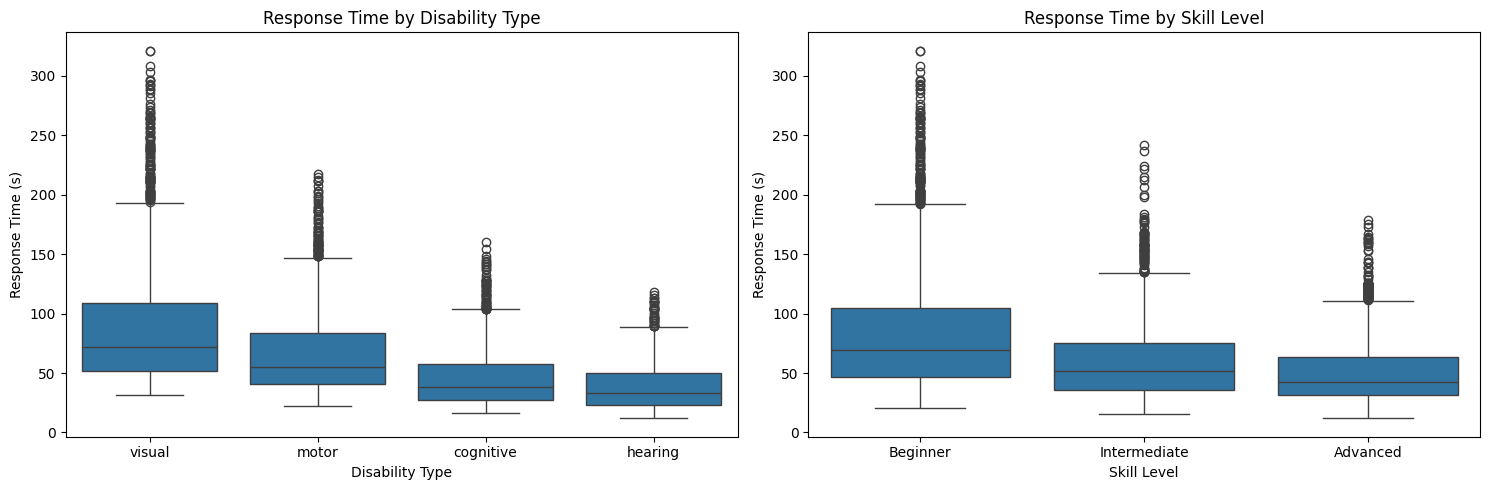

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='disability_type', y='response_time_seconds', ax=axes[0],
            order=['visual', 'motor', 'cognitive', 'hearing'])
axes[0].set_title('Response Time by Disability Type')
axes[0].set_xlabel('Disability Type')
axes[0].set_ylabel('Response Time (s)')

sns.boxplot(data=df, x='true_skill_label', y='response_time_seconds', ax=axes[1],
            order=['Beginner', 'Intermediate', 'Advanced'])
axes[1].set_title('Response Time by Skill Level')
axes[1].set_xlabel('Skill Level')
axes[1].set_ylabel('Response Time (s)')

plt.tight_layout()
plt.show()

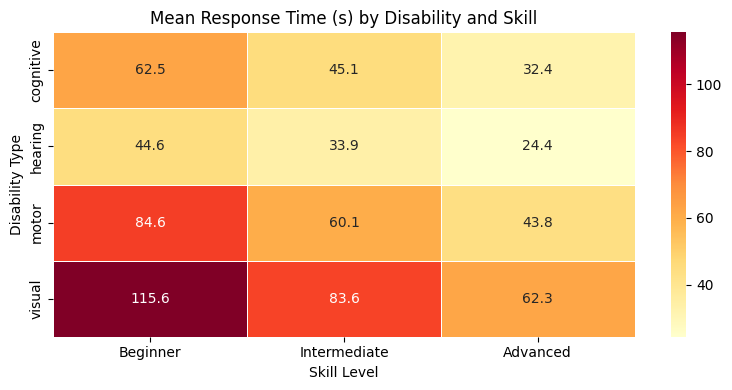

In [5]:
heat = df.groupby(['disability_type', 'true_skill_label'])['response_time_seconds'].mean().unstack()
heat = heat[['Beginner', 'Intermediate', 'Advanced']]

plt.figure(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=.5)
plt.title('Mean Response Time (s) by Disability and Skill')
plt.ylabel('Disability Type')
plt.xlabel('Skill Level')
plt.tight_layout()
plt.show()

## Feature Engineering



In [6]:
agg = df.groupby(['user_id', 'course_id', 'disability_type', 'true_skill_label']).agg(
    num_questions     = ('question_number', 'count'),
    avg_difficulty    = ('question_difficulty', 'mean'),
    max_difficulty    = ('question_difficulty', 'max'),
    accuracy          = ('is_correct', 'mean'),
    total_correct     = ('is_correct', 'sum'),
    avg_response_time = ('response_time_seconds', 'mean'),
    std_response_time = ('response_time_seconds', 'std'),
    max_response_time = ('response_time_seconds', 'max'),
    min_response_time = ('response_time_seconds', 'min'),
).reset_index()

agg['std_response_time'] = agg['std_response_time'].fillna(0)
agg['time_range'] = agg['max_response_time'] - agg['min_response_time']
agg['time_per_difficulty'] = agg['avg_response_time'] / agg['avg_difficulty']

print("Aggregated shape:", agg.shape)
agg.head()

Aggregated shape: (527, 15)


,user_id,course_id,disability_type,true_skill_label,num_questions,avg_difficulty,max_difficulty,accuracy,total_correct,avg_response_time,std_response_time,max_response_time,min_response_time,time_range,time_per_difficulty
0,user_0,digital_marketing,hearing,Intermediate,11,1.909091,3,0.727273,8,37.618182,23.495566,78.5,15.7,62.8,19.704762
1,user_0,freelancing_khamsat,hearing,Intermediate,12,1.916667,3,0.583333,7,39.675000,23.621759,79.9,18.1,61.8,20.700000
2,user_0,testing,hearing,Intermediate,14,1.428571,2,0.857143,12,23.835714,6.452621,33.7,15.6,18.1,16.685000
3,user_1,digital_marketing,visual,Advanced,13,1.923077,3,0.846154,11,71.376923,41.742727,160.2,33.0,127.2,37.116000
4,user_1,embedded,visual,Advanced,15,1.133333,2,1.000000,15,42.126667,8.832041,66.1,32.1,34.0,37.170588


In [7]:
disability_map = {'visual': 0, 'motor': 1, 'cognitive': 2, 'hearing': 3}
agg['disability_encoded'] = agg['disability_type'].map(disability_map)

label_map = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
agg['target'] = agg['true_skill_label'].map(label_map)

FEATURES = [
    'disability_encoded', 'num_questions', 'avg_difficulty', 'max_difficulty',
    'accuracy', 'total_correct', 'avg_response_time', 'std_response_time',
    'max_response_time', 'min_response_time', 'time_range', 'time_per_difficulty'
]

X = agg[FEATURES]
y = agg['target']
groups = agg['user_id']

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index().rename(index={0: "Beginner", 1: "Intermediate", 2: "Advanced"}))

X shape: (527, 12)
Target distribution:
target
Beginner        211
Intermediate    153
Advanced        163
Name: count, dtype: int64


## Train / Test Split


In [8]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_users = groups.iloc[train_idx].unique()
test_users = groups.iloc[test_idx].unique()
overlap = len(set(train_users) & set(test_users))

print(f"Train: {X_train.shape[0]} samples from {len(train_users)} users")
print(f"Test:  {X_test.shape[0]} samples from {len(test_users)} users")
print(f"User overlap: {overlap}")

Train: 425 samples from 80 users
Test:  102 samples from 20 users
User overlap: 0


## Model Training — Baseline

In [9]:
models = {
    'Decision Tree':      DecisionTreeClassifier(random_state=42),
    'Random Forest':      RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingClassifier(random_state=42),
    'XGBoost':            XGBClassifier(random_state=42, use_label_encoder=False,
                                        eval_metric='mlogloss', verbosity=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42,
                                              multi_class='multinomial'),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test, y_test)
    results[name] = {'train_acc': train_acc, 'test_acc': test_acc}
    print(f"{name:25s}  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}")

Decision Tree              Train: 1.0000  |  Test: 0.9608
Random Forest              Train: 1.0000  |  Test: 0.8627
Gradient Boosting          Train: 1.0000  |  Test: 0.9706
XGBoost                    Train: 1.0000  |  Test: 0.9608
Logistic Regression        Train: 0.9624  |  Test: 0.9216


c:\Users\pc\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Hyperparameter Tuning

In [10]:
gkf = GroupKFold(n_splits=5)

param_grids = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 3, 5],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 3],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False,
                               eval_metric='mlogloss', verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0],
        }
    },
}

tuned_results = {}

for name, cfg in param_grids.items():
    print(f"Tuning {name} ...")
    grid = GridSearchCV(
        cfg['model'], cfg['params'],
        cv=gkf, scoring='accuracy',
        n_jobs=-1, refit=True
    )
    grid.fit(X_train, y_train, groups=groups.iloc[train_idx])

    train_acc = grid.best_estimator_.score(X_train, y_train)
    test_acc  = grid.best_estimator_.score(X_test, y_test)

    tuned_results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_score': grid.best_score_,
    }

    print(f"  Best params: {grid.best_params_}")
    print(f"  CV accuracy: {grid.best_score_:.4f}")
    print(f"  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}")
    print()

Tuning Decision Tree ...
  Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
  CV accuracy: 0.9294
  Train: 0.9976  |  Test: 0.9510

Tuning Random Forest ...
  Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
  CV accuracy: 0.8541
  Train: 1.0000  |  Test: 0.8431

Tuning XGBoost ...
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
  CV accuracy: 0.9459
  Train: 1.0000  |  Test: 0.9608



In [11]:
rows = []
for name in param_grids:
    rows.append({
        'Model': name,
        'Baseline Test': results[name]['test_acc'],
        'Tuned CV': tuned_results[name]['cv_score'],
        'Tuned Test': tuned_results[name]['test_acc'],
        'Improvement': tuned_results[name]['test_acc'] - results[name]['test_acc'],
    })

comp_df = pd.DataFrame(rows).set_index('Model')
print(comp_df.round(4).to_string())

best_name = max(tuned_results, key=lambda k: tuned_results[k]['test_acc'])
best_model = tuned_results[best_name]['model']
print(f"\nBest model: {best_name}")
print(f"Test accuracy: {tuned_results[best_name]['test_acc']:.4f}")
print(f"Best params: {tuned_results[best_name]['best_params']}")

               Baseline Test  Tuned CV  Tuned Test  Improvement
Model                                                          
Decision Tree         0.9608    0.9294      0.9510      -0.0098
Random Forest         0.8627    0.8541      0.8431      -0.0196
XGBoost               0.9608    0.9459      0.9608       0.0000

Best model: XGBoost
Test accuracy: 0.9608
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}


## Evaluation of Best Model

In [12]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Beginner', 'Intermediate', 'Advanced']))

              precision    recall  f1-score   support

    Beginner       0.98      1.00      0.99        57
Intermediate       1.00      0.83      0.90        23
    Advanced       0.88      1.00      0.94        22

    accuracy                           0.96       102
   macro avg       0.95      0.94      0.94       102
weighted avg       0.96      0.96      0.96       102



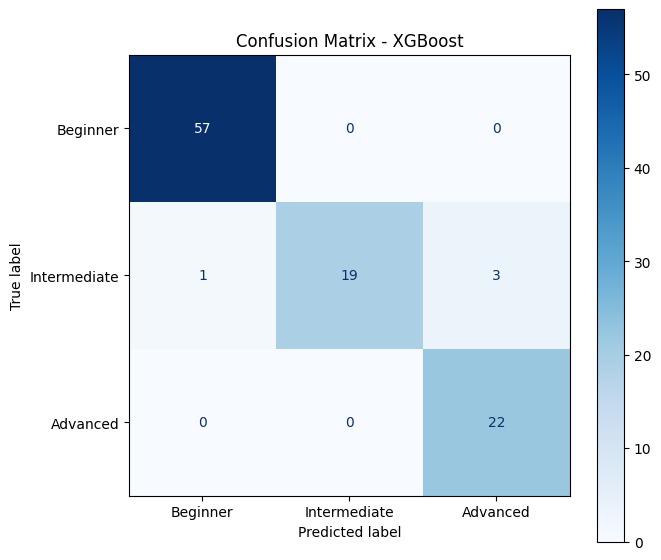

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Beginner', 'Intermediate', 'Advanced'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

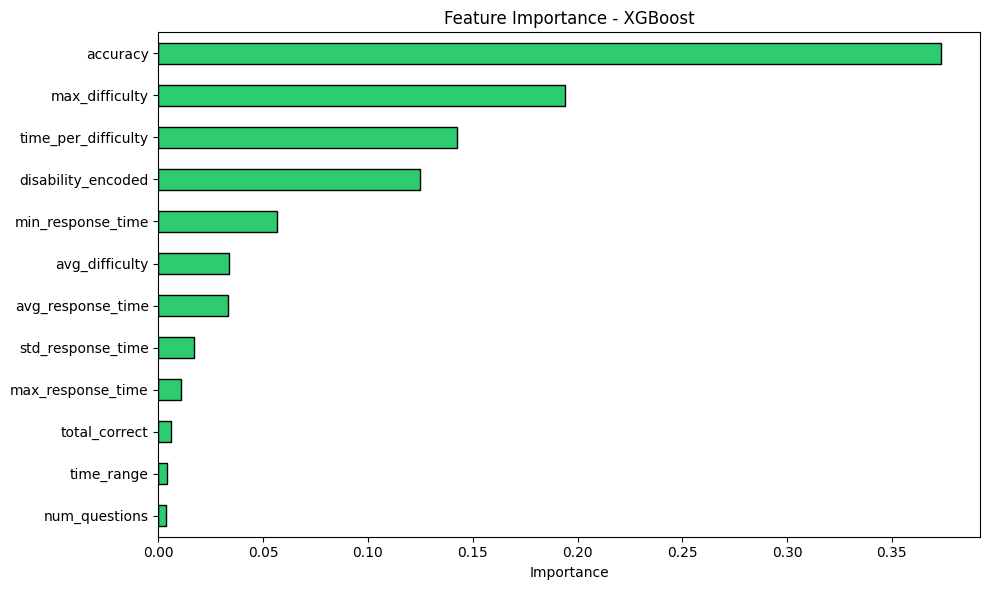

In [14]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp.plot.barh(figsize=(10, 6), color='#2ecc71', edgecolor='black')
    plt.title(f'Feature Importance - {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## Export Best Model

In [15]:
MODEL_DIR = os.path.join('..', 'src', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, 'skill_predictor.pkl')
joblib.dump({
    'model': best_model,
    'features': FEATURES,
    'label_map': label_map,
    'disability_map': disability_map,
    'model_name': best_name,
    'test_accuracy': tuned_results[best_name]['test_acc'],
    'best_params': tuned_results[best_name]['best_params'],
    'cv_score': tuned_results[best_name]['cv_score'],
}, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"Model saved to {model_path} ({size_kb:.1f} KB)")
print(f"Model: {best_name}")
print(f"Test Accuracy: {tuned_results[best_name]['test_acc']:.4f}")
print(f"CV Score: {tuned_results[best_name]['cv_score']:.4f}")

Model saved to ..\src\models\skill_predictor.pkl (867.1 KB)
Model: XGBoost
Test Accuracy: 0.9608
CV Score: 0.9459
